In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
df.index.name = 'Month'
print(df.shape)
df.head()

(54, 5)


,CPU,Mother Board,RAM,Storage,Video Card
Month,,,,,
2013-06-01,NaN,NaN,NaN,119.0,NaN
2013-07-01,NaN,NaN,NaN,0.0,NaN
2013-08-01,NaN,NaN,NaN,0.0,NaN
2013-09-01,NaN,NaN,NaN,0.0,NaN
2013-10-01,NaN,NaN,NaN,0.0,NaN


In [3]:
df.describe()          # min, max, mean per category
df.isna().sum()         # any leftover missing values per category
df.sum().sort_values(ascending=False)   # total demand by category — which product line is biggest

Storage         4943.0
CPU             4851.0
Video Card      2964.0
Mother Board    2880.0
RAM             1189.0
dtype: float64

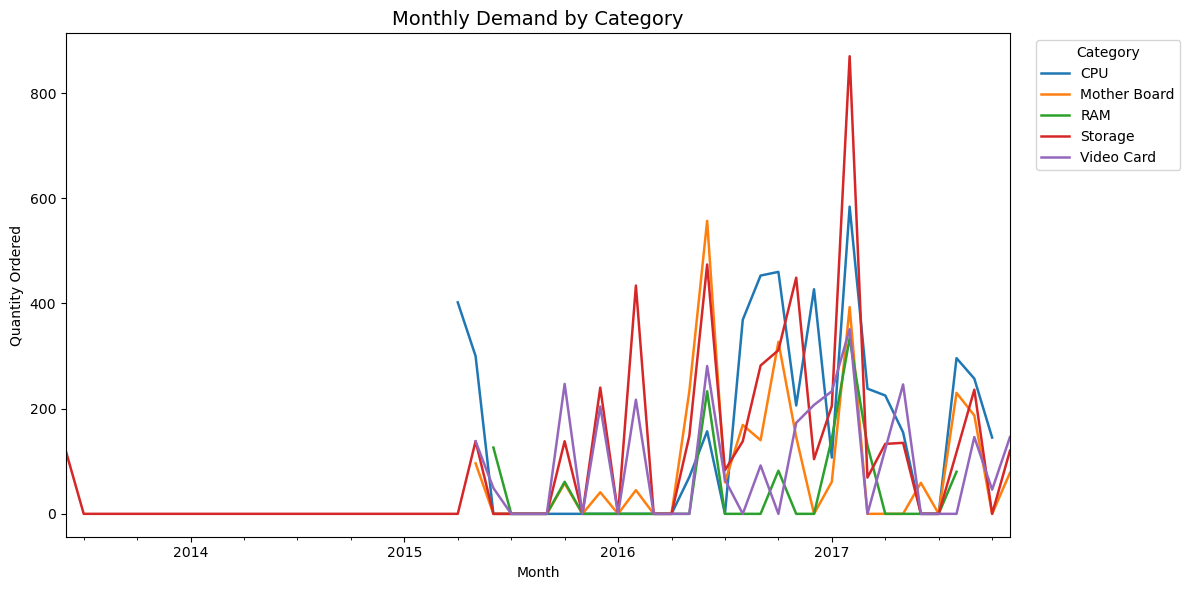

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
df.plot(ax=ax, linewidth=1.8)
ax.set_title('Monthly Demand by Category', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Quantity Ordered')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

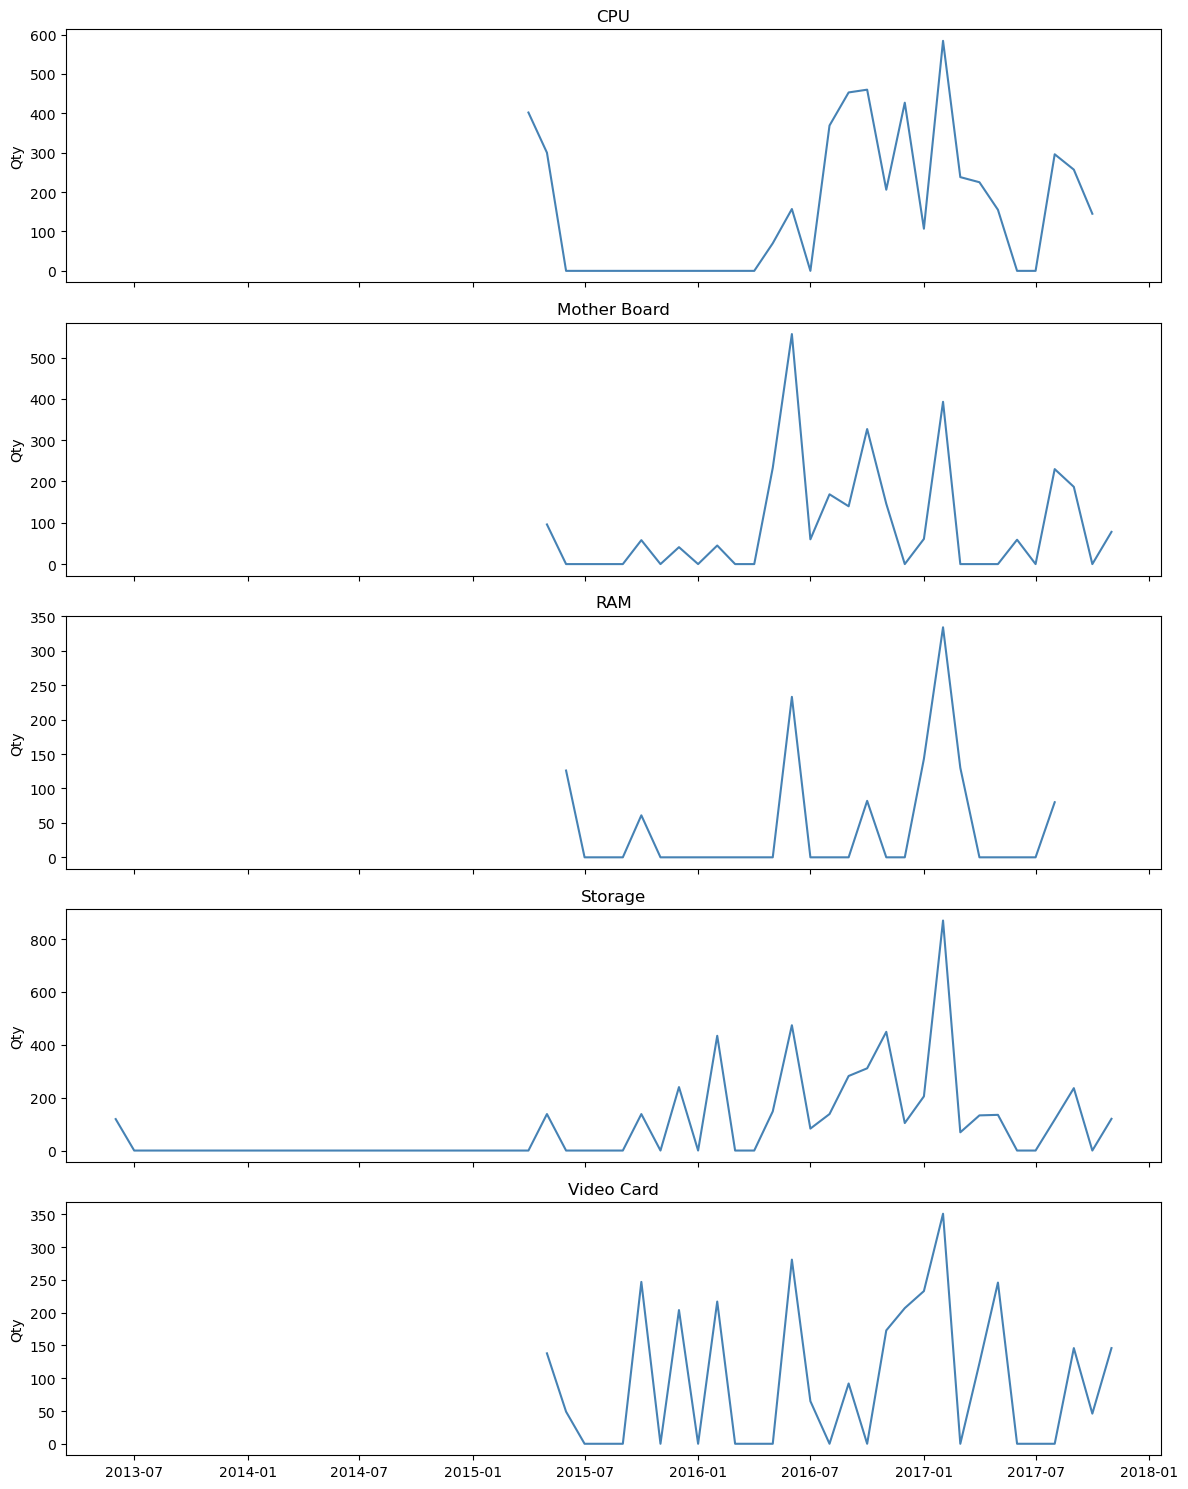

In [5]:
categories = df.columns.tolist()
fig, axes = plt.subplots(len(categories), 1, figsize=(12, 3*len(categories)), sharex=True)

for ax, cat in zip(axes, categories):
    ax.plot(df.index, df[cat], color='steelblue')
    ax.set_title(cat)
    ax.set_ylabel('Qty')

plt.tight_layout()
plt.show()

In [6]:
import io

sample_data = """Month,Category,Value,IsAnomaly
2017-02-01,CPU,586,True
2017-08-01,Storage,880,True
"""

anomalies = pd.read_csv(io.StringIO(sample_data), parse_dates=['Month'])
anomalies.head()

,Month,Category,Value,IsAnomaly
0,2017-02-01,CPU,586,True
1,2017-08-01,Storage,880,True


In [7]:
print(anomalies.dtypes)
anomalies.head()

Month        datetime64[ns]
Category             object
Value                 int64
IsAnomaly              bool
dtype: object


,Month,Category,Value,IsAnomaly
0,2017-02-01,CPU,586,True
1,2017-08-01,Storage,880,True


In [8]:
anomalies['IsAnomaly'] = anomalies['IsAnomaly'].astype(bool)

In [9]:
anom_points = anomalies[anomalies['IsAnomaly'] == True]
anom_points

,Month,Category,Value,IsAnomaly
0,2017-02-01,CPU,586,True
1,2017-08-01,Storage,880,True


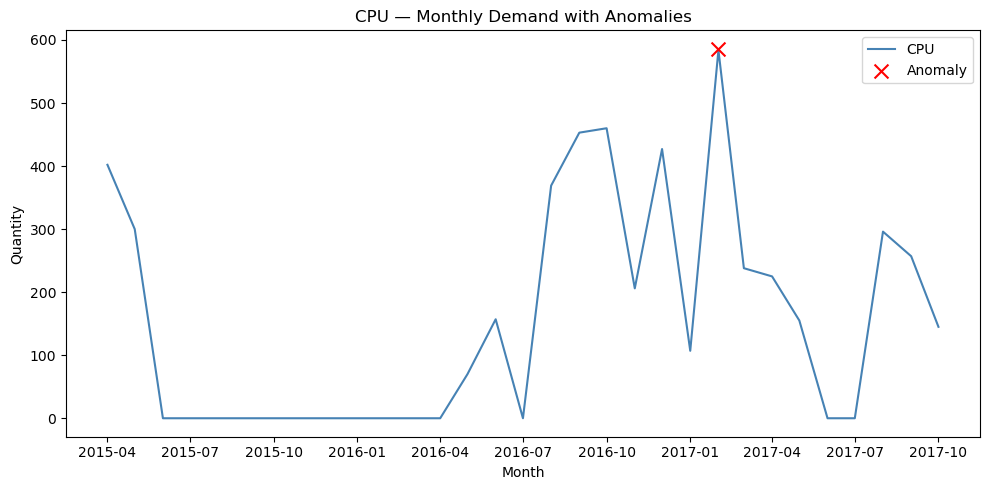

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# the full trend line
ax.plot(df.index, df['CPU'], color='steelblue', linewidth=1.5, label='CPU')

# overlay only CPU's anomaly points
cpu_anom = anom_points[anom_points['Category'] == 'CPU']
ax.scatter(cpu_anom['Month'], cpu_anom['Value'], color='red', marker='x', s=100, label='Anomaly', zorder=5)

ax.set_title('CPU — Monthly Demand with Anomalies')
ax.set_xlabel('Month')
ax.set_ylabel('Quantity')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt

def plot_category_trend(df, category, anomalies=None, figsize=(10, 4)):
    """Plot demand trend for one category, with anomaly points overlaid if provided."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df[category], color='steelblue', linewidth=1.5, label=category)

    if anomalies is not None and not anomalies.empty:
        cat_anom = anomalies[(anomalies['Category'] == category) & (anomalies['IsAnomaly'] == True)]
        ax.scatter(cat_anom['Month'], cat_anom['Value'], color='red', marker='x', s=80, label='Anomaly', zorder=5)

    ax.set_title(f'{category} — Monthly Demand')
    ax.set_xlabel('Month')
    ax.set_ylabel('Quantity')
    ax.legend()
    fig.tight_layout()
    return fig

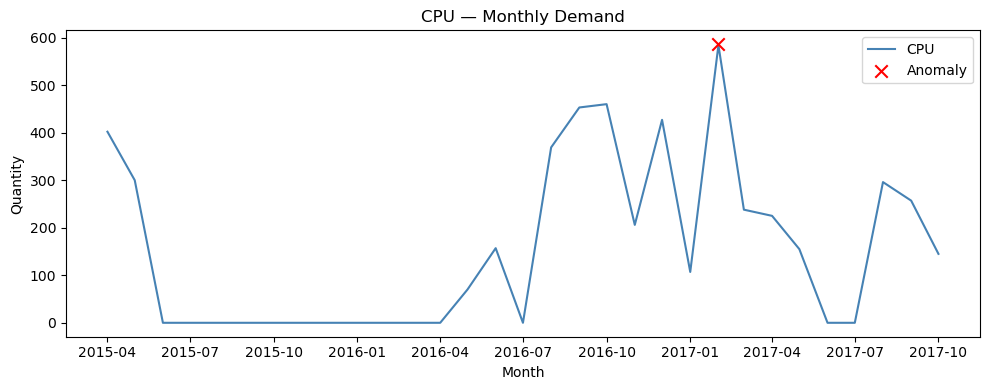

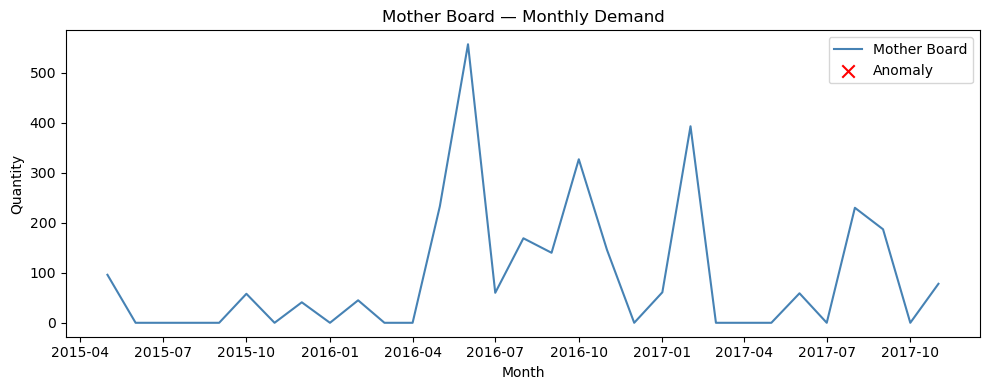

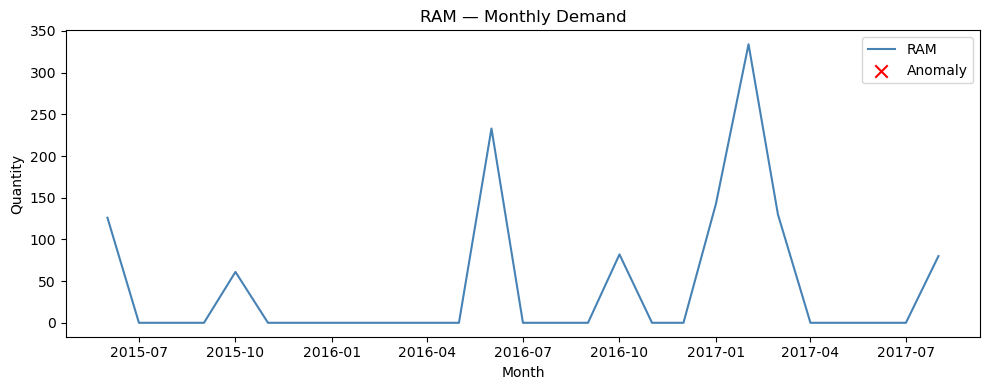

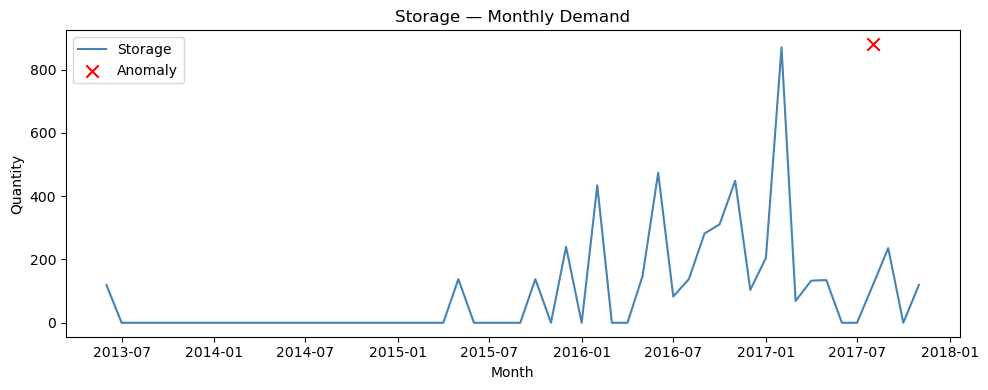

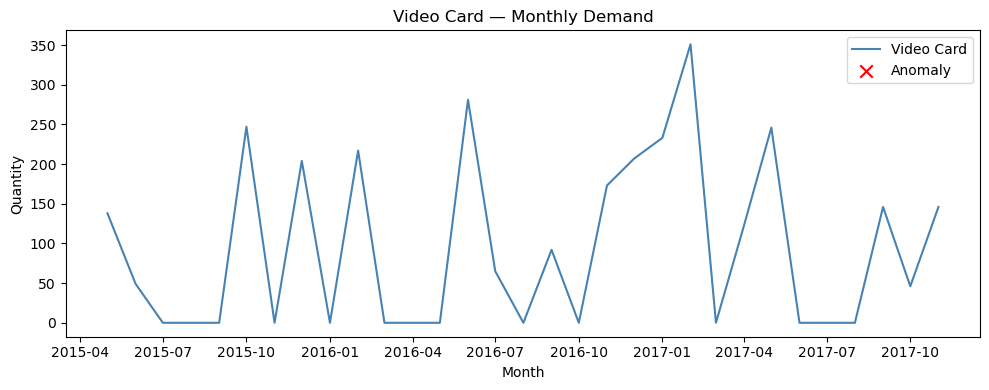

In [12]:
for cat in df.columns:
    fig = plot_category_trend(df, cat, anomalies)
    plt.show()

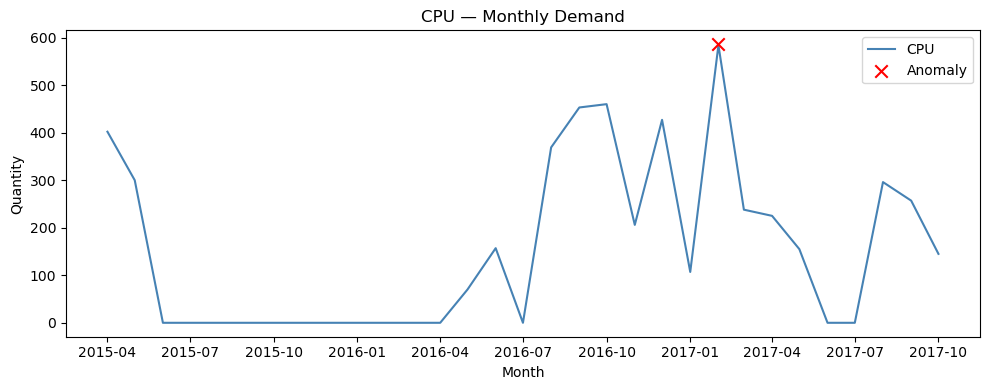

In [13]:
fig = plot_category_trend(df, 'CPU', anomalies)
plt.show()

In [14]:
import os
print(os.getcwd())          # confirms where your notebook is running from
print(os.listdir('.'))       # do you see a 'figures' folder here?

D:\2ndproject_Groupno5_Infotact\2ndproject_Groupno5_Infotact
['.ipynb_checkpoints', '2nd month project_dataset.html', 'configure gitignore.html', 'Customer.csv', 'Day4_Visualization.ipynb', 'Employee.csv', 'figures', 'inspect raw supply chain datasets.html', 'merged_supply_chain.csv', 'monthly_demand_clean.csv', 'monthly_demand_plot.png', 'OrderDetails.csv', 'Orders.csv', 'Product.csv', 'README.md', 'Region.csv', 'requirements.txt', 'Time-Series Preparation.html', 'Warehouse.csv', 'Week1work.html']


In [15]:
import os

os.makedirs('figures', exist_ok=True)

# 1. combined overview chart
fig, ax = plt.subplots(figsize=(12, 6))
df.plot(ax=ax)
ax.set_title('Monthly Demand by Category')
fig.tight_layout()
fig.savefig('figures/monthly_demand_overview.png', dpi=150)
plt.close(fig)
print("Saved: figures/monthly_demand_overview.png")

# 2. one chart per category, using your Day 19/20 function
for cat in df.columns:
    fig = plot_category_trend(df, cat, anomalies)
    safe_name = cat.lower().replace(' ', '_')
    filepath = f'figures/{safe_name}_trend.png'
    fig.savefig(filepath, dpi=150)
    plt.close(fig)
    print(f"Saved: {filepath}")

Saved: figures/monthly_demand_overview.png
Saved: figures/cpu_trend.png
Saved: figures/mother_board_trend.png
Saved: figures/ram_trend.png
Saved: figures/storage_trend.png
Saved: figures/video_card_trend.png


In [16]:
os.listdir('figures')

['cpu_trend.png',
 'monthly_demand_overview.png',
 'mother_board_trend.png',
 'ram_trend.png',
 'storage_trend.png',
 'video_card_trend.png']

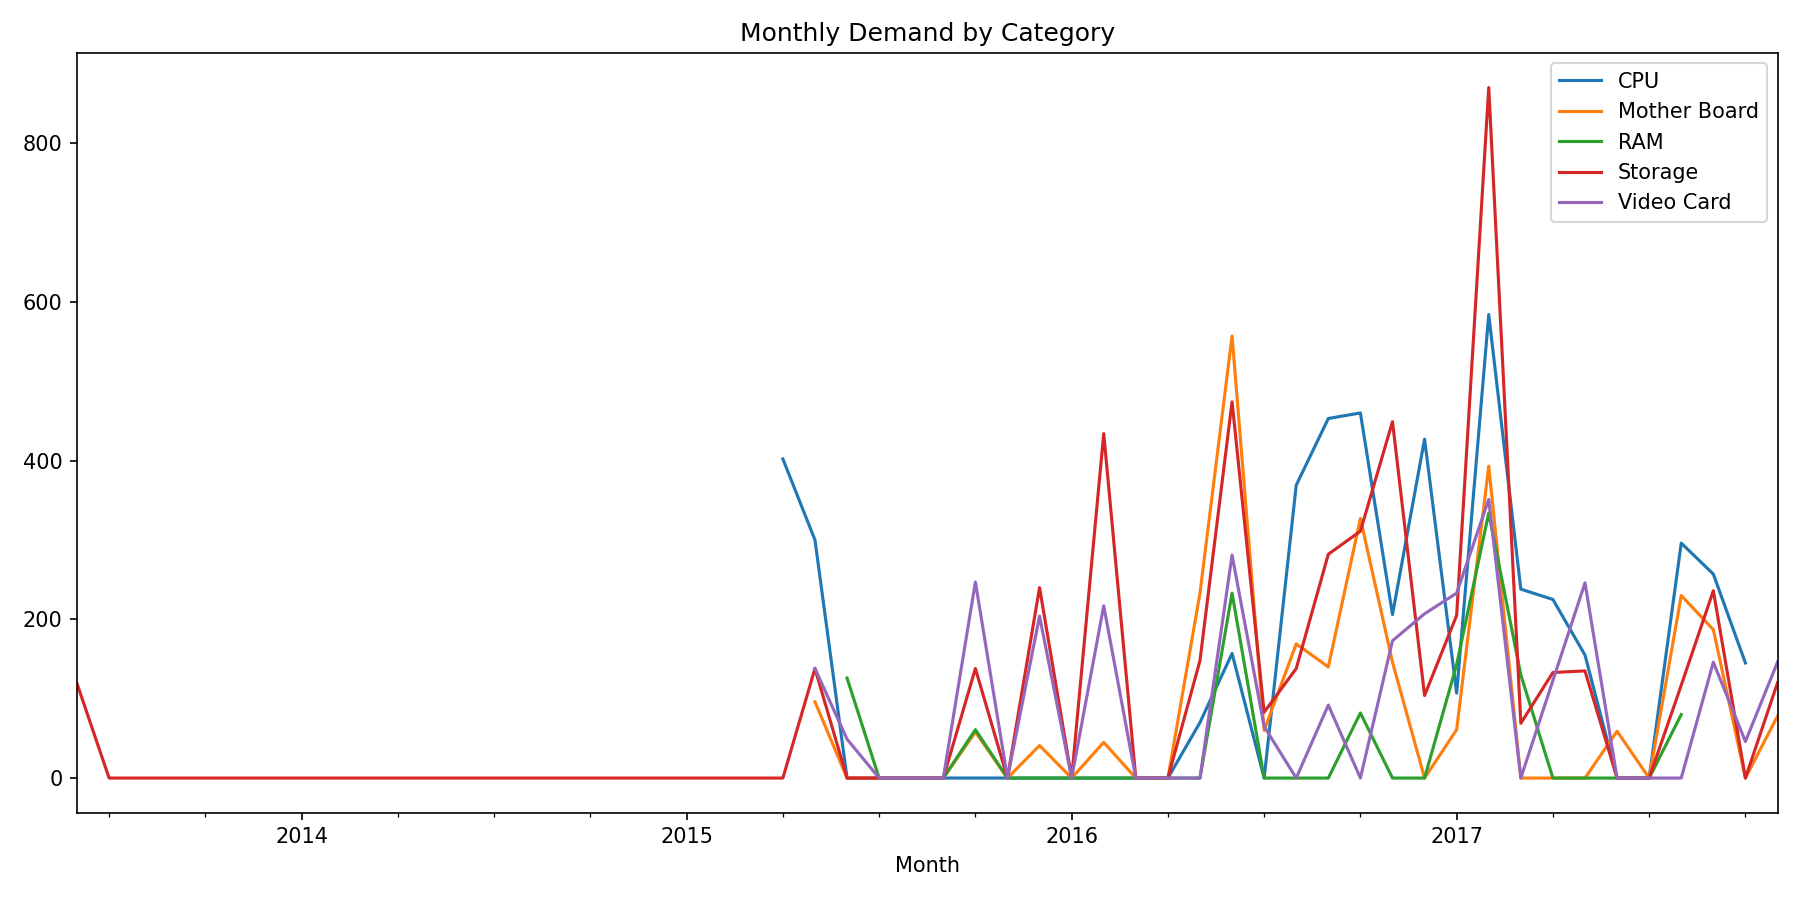

In [17]:
from IPython.display import Image, display
display(Image('figures/monthly_demand_overview.png'))

In [18]:
# viz_utils.py
import pandas as pd
import matplotlib.pyplot as plt

def load_demand_data(path='monthly_demand_clean.csv'):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    return df

def load_anomalies(path='anomalies.csv'):
    try:
        return pd.read_csv(path, parse_dates=['Month'])
    except FileNotFoundError:
        return pd.DataFrame(columns=['Month', 'Category', 'Value', 'IsAnomaly'])

def plot_category_trend(df, category, anomalies=None, figsize=(10, 4)):
    # (same function as Day 20)
    ...

def get_summary_stats(df):
    """Returns per-category totals/means — useful for dashboard KPI cards."""
    return df.agg(['sum', 'mean', 'max']).T

In [19]:
%%writefile viz_utils.py
import pandas as pd
import matplotlib.pyplot as plt

def load_demand_data(path='monthly_demand_clean.csv'):
    """Load the cleaned monthly demand dataset."""
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    return df

def load_anomalies(path='anomalies.csv'):
    """Load anomaly flags. Returns an empty dataframe if the file doesn't exist yet."""
    try:
        return pd.read_csv(path, parse_dates=['Month'])
    except FileNotFoundError:
        return pd.DataFrame(columns=['Month', 'Category', 'Value', 'IsAnomaly'])

def plot_category_trend(df, category, anomalies=None, figsize=(10, 4)):
    """Plot demand trend for one category, with anomaly points overlaid if provided."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df[category], color='steelblue', linewidth=1.5, label=category)
    if anomalies is not None and not anomalies.empty:
        cat_anom = anomalies[(anomalies['Category'] == category) & (anomalies['IsAnomaly'] == True)]
        ax.scatter(cat_anom['Month'], cat_anom['Value'], color='red', marker='x', s=80, label='Anomaly', zorder=5)
    ax.set_title(f'{category} - Monthly Demand')
    ax.set_xlabel('Month')
    ax.set_ylabel('Quantity')
    ax.legend()
    fig.tight_layout()
    return fig

def get_summary_stats(df):
    """Returns per-category totals/mean/max — useful for dashboard KPI cards."""
    return df.agg(['sum', 'mean', 'max']).T

Writing viz_utils.py


In [20]:
import os
print(os.path.exists('viz_utils.py'))
print(os.listdir('.'))

True
['.ipynb_checkpoints', '2nd month project_dataset.html', 'configure gitignore.html', 'Customer.csv', 'Day4_Visualization.ipynb', 'Employee.csv', 'figures', 'inspect raw supply chain datasets.html', 'merged_supply_chain.csv', 'monthly_demand_clean.csv', 'monthly_demand_plot.png', 'OrderDetails.csv', 'Orders.csv', 'Product.csv', 'README.md', 'Region.csv', 'requirements.txt', 'Time-Series Preparation.html', 'viz_utils.py', 'Warehouse.csv', 'Week1work.html']


                 sum        mean    max
CPU           4851.0  156.483871  584.0
Mother Board  2880.0   92.903226  557.0
RAM           1189.0   44.037037  334.0
Storage       4943.0   91.537037  870.0
Video Card    2964.0   95.612903  351.0


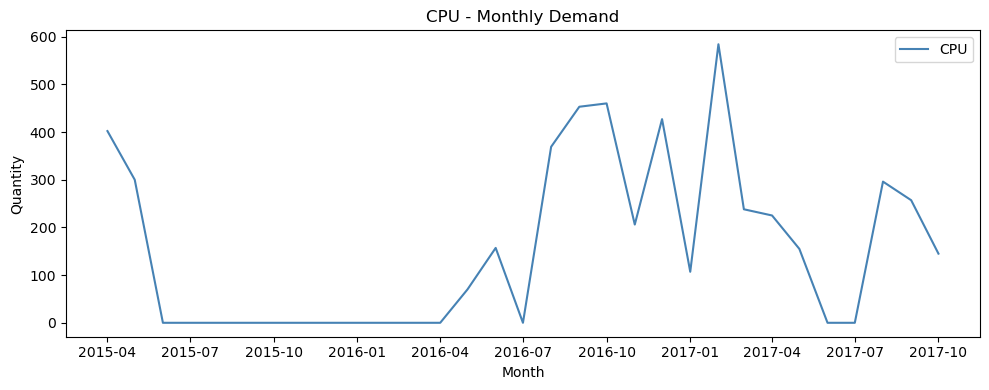

In [21]:
from viz_utils import load_demand_data, plot_category_trend, get_summary_stats
import matplotlib.pyplot as plt

df = load_demand_data('monthly_demand_clean.csv')
print(get_summary_stats(df))

fig = plot_category_trend(df, 'CPU')
plt.show()